# Train HeatGeo from GitHub (Colab)

In [ ]:
#@title 1. Cấu hình experiment
REPO_URL = "https://github.com/Savoxism/embedding-kd.git"
BRANCH = "nqd_mass_geom_loss"

PAIR_KEY = "qwen3_4b_to_bert_base" #@param
# ["qwen3_0_6b_to_minilmv2_h384", "bge_m3_to_minilmv2_h768", "qwen3_4b_to_bert_base"]

# Bề mặt hyperparam sau đợt thu gọn:
# - diffusion_quota: DERIVED từ graph artifact (coverage tau=0.7, policy.py) —
#   không còn là knob; log in "Derived diffusion_quota=..." mỗi run.
# - deterministic_topm: policy constant; direct_temp: default 0.1 (đo được flat
#   trên minilm; --direct_temp 0 derive từ median bandwidth của graph).
# - hard_neg_k/random_neg_k, learning_rate: default config = arm thắng (40/26, 3e-5).
# Muốn ablation knob nào thì truyền qua EXTRA_ARGS và đổi RUN_NAME.
ROW_WEIGHT = 1.0 #@param {type:"number"}
ROW_START_EPOCH = 1 #@param {type:"integer"}

RUN_NAME = "base" #@param {type:"string"}

BATCH_SIZE = 64 #@param {type:"integer"}
EPOCHS = 5 #@param {type:"integer"}
# 3e-5 là arm thắng từ config; run 77.89 trước đó chạy 2e-5 và có chữ ký
# undertrain rõ (loss còn giảm ở epoch 4→5, student_top1 còn tăng).
LEARNING_RATE = 3e-5 #@param {type:"number"}
MAX_LENGTH = 256 #@param {type:"integer"}
SEED = 42 #@param {type:"integer"}
NUM_WORKERS = 4 #@param {type:"integer"}
TRAIN_DATA = "data/train_set/merged_3_data_5k_each.csv" #@param {type:"string"}

FINAL_WEIGHTS_ONLY = True #@param {type:"boolean"}
REQUIRE_GPU = True #@param {type:"boolean"}

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_ROOT = "/content/drive/MyDrive/embedding-kd-runs" #@param {type:"string"}

# Thêm CLI flags nếu cần — xem cell "Kế hoạch chạy" ngay dưới cho các arm:
#   --unbiased_geometry_weight 0.5   (L_geo: đóng shift-degeneracy)
#   --direct_temp 0                  (derive tau_0 = median graph bandwidth)
#   --diffusion_scales 1             (bỏ multi-hop; nhớ đổi heatgeo_cache_path!)
# Chú ý: knob trong EXTRA_ARGS KHÔNG vào RUN_TAG — arm dùng EXTRA_ARGS phải đổi
# RUN_NAME để không ghi đè.
EXTRA_ARGS = "" #@param {type:"string"}

assert ROW_WEIGHT >= 0, "ROW_WEIGHT phải không âm"
assert ROW_START_EPOCH >= 1, "ROW_START_EPOCH phải bắt đầu từ 1"
assert BATCH_SIZE > 0 and EPOCHS > 0 and MAX_LENGTH > 0

# Mỗi arm ghi vào thư mục riêng để các run không đè lên nhau. "qauto" đánh dấu
# quota derived và tách thư mục khỏi các run cũ dùng quota chỉnh tay.
RUN_TAG = (
    f"{RUN_NAME}_w{ROW_WEIGHT:g}_e{ROW_START_EPOCH}"
    f"_qauto_lr{LEARNING_RATE:g}_seed{SEED}"
)


## Kế hoạch chạy → 78.5 avg (qwen3_4b_to_bert_base)

Mốc hiện tại: **77.89** (lr 2e-5, defaults, seed 42, run `20260831-171700-ef911d`) — còn thiếu **+0.61**.
Chạy tuần tự theo thứ tự dưới; mỗi arm chỉ đổi `RUN_NAME` + `EXTRA_ARGS` (và `LEARNING_RATE` nếu ghi) rồi Run all. Teacher cache + graph dùng chung, chỉ build một lần.

| # | Arm | RUN_NAME | Cài đặt | Kỳ vọng |
|---|---|---|---|---|
| A | **lr đúng** | `base` | `LEARNING_RATE=3e-5`, EXTRA_ARGS trống | Gain chính. Run 77.89 undertrain rõ: loss còn giảm epoch 4→5, `student_top1` còn tăng. Trên minilm 3e-5 là arm thắng. |
| B | **L_geo** | `geo_w0.5` | lr 3e-5 + `--unbiased_geometry_weight 0.5` | Gain calibration (pair/STS). Mọi term KL đều bất biến shift per-anchor; L_geo là term duy nhất ghim mức cosine tuyệt đối — đúng thứ `best_threshold` đang dao động 0.82–0.92 giữa các pair task cần. Nếu B > A, thử thêm `geo_w1.0`. |
| C | **τ₀ derived** | `tau0_derived` | lr 3e-5 + `--direct_temp 0` | Trên cặp này derived ≈ `row_temp_p50` = **0.053**, sharper hẳn 0.10 — không chắc flat như minilm. Nếu thắng: vừa gain vừa xóa nhiệt độ tự do cuối cùng. |
| D | **R={1}** | `scales_r1` | lr 3e-5 + `--diffusion_scales 1 --heatgeo_cache_path cache/heatgeo/qwen3_4b_to_bert_base/graph_r1.pt` | Kiểm tra flat (đọc trước `scale_divergence` của run A: gần 0 → ladder trang trí). **Phải** đổi cache path vì scale set khác sẽ rebuild graph. |
| E | **hard:random flat** | `negs_33_33` | lr 3e-5 + `--hard_neg_k 33 --random_neg_k 33` | Kiểm tra flat cùng tổng budget 66 → mở khóa single-budget knob. |
| F | **Combine** | `flagship` | lr 3e-5 + các arm thắng ở B/C | Arm nộp bài. |

Đọc miễn phí từ mọi run (metrics mới): `amb_diff_js_own`, `amb_mass_on_zero_diff` — phần "cãi nhau" ambient↔diffusion còn lại trên hard negatives trong own draw. Nếu `amb_mass_on_zero_diff` lớn (>0.3) và JS cao, arm tiếp theo là thu hẹp diffusion domain.

Lưu ý: `perplexity_clamped_rate = 25.8%` trên cặp này (3497 rows clamp) — nếu A–F chưa đủ 78.5, thử `--graph_k 300` (giảm clamp, đổi cache path) hoặc `--perplexity 20`.


In [11]:
# 2. Clone lần đầu; các lần Run all sau luôn fetch/reset/pull branch mới nhất
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/embedding-kd")

def git(*args):
    command = ["git", "-C", str(REPO_DIR), *args]
    print("+", " ".join(command))
    subprocess.run(command, check=True)

if (REPO_DIR / ".git").is_dir():
    git("remote", "set-url", "origin", REPO_URL)
    # Bỏ thay đổi tracked trong clone Colab để luôn checkout được remote head.
    git("reset", "--hard")
    git("fetch", "--prune", "origin")
    git("checkout", "-B", BRANCH, f"origin/{BRANCH}")
    git("reset", "--hard", f"origin/{BRANCH}")
    git("pull", "--ff-only", "origin", BRANCH)
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} tồn tại nhưng không phải Git repository")
else:
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)],
        check=True,
    )

commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print(f"Ready: {BRANCH}@{commit[:12]}")


+ git -C /content/embedding-kd remote set-url origin https://github.com/Savoxism/embedding-kd.git
+ git -C /content/embedding-kd reset --hard
+ git -C /content/embedding-kd fetch --prune origin
+ git -C /content/embedding-kd checkout -B nqd_mass_geom_loss origin/nqd_mass_geom_loss
+ git -C /content/embedding-kd reset --hard origin/nqd_mass_geom_loss
+ git -C /content/embedding-kd pull --ff-only origin nqd_mass_geom_loss
Ready: nqd_mass_geom_loss@ed1e3a62e976


In [12]:
# 3. Cài/đồng bộ dependencies theo code vừa pull
import os
import sys

os.chdir(REPO_DIR)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements.txt")],
    check=True,
)
print("Dependencies are ready.")


Dependencies are ready.


In [13]:
# 4. Resolve model pair, GPU và nơi lưu artifacts
import torch

PAIR_CONFIGS = {
    "qwen3_0_6b_to_minilmv2_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "pooling": "last_token",
    },
    "bge_m3_to_minilmv2_h768": {
        "teacher": "BAAI/bge-m3",
        "student": "nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base",
        "pooling": "cls",
    },
    "qwen3_4b_to_bert_base": {
        "teacher": "Qwen/Qwen3-Embedding-4B",
        "student": "google-bert/bert-base-uncased",
        "pooling": "last_token",
    },
}
pair = PAIR_CONFIGS[PAIR_KEY]

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("Không tìm thấy CUDA GPU. Trong Colab chọn Runtime → Change runtime type → GPU.")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 2**30
    print(f"GPU: {props.name} ({vram_gb:.1f} GiB)")
    if PAIR_KEY == "qwen3_4b_to_bert_base" and vram_gb < 35:
        print("WARNING: Qwen3-4B ở cấu hình hiện tại có thể OOM trên GPU dưới khoảng 35 GiB.")

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    artifact_root = Path(DRIVE_ROOT)
else:
    artifact_root = REPO_DIR

# cache_dir không mang RUN_TAG: teacher embeddings và HeatGeo graph không phụ
# thuộc row mode, nên ba variant dùng chung một cache và chỉ build graph một lần.
cache_dir = artifact_root / "cache" / "heatgeo" / PAIR_KEY
log_dir = artifact_root / "logs" / "heatgeo" / PAIR_KEY
save_dir = artifact_root / "models" / "heatgeo" / PAIR_KEY / RUN_TAG
weights_dir = artifact_root / "models" / "heatgeo_weights" / PAIR_KEY / RUN_TAG
for path in (cache_dir, log_dir, save_dir, weights_dir):
    path.mkdir(parents=True, exist_ok=True)

print(f"Teacher: {pair['teacher']}")
print(f"Student: {pair['student']}")
print(f"Pooling: {pair['pooling']}")
print(f"Objective: L_rel + {ROW_WEIGHT} * L_row")
print(f"Row starts at epoch: {ROW_START_EPOCH}")
print(f"Outputs: {save_dir}")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Teacher: Qwen/Qwen3-Embedding-4B
Student: google-bert/bert-base-uncased
Pooling: last_token
Objective: L_rel + 1.0 * L_row
Row starts at epoch: 1
Outputs: /content/embedding-kd/models/heatgeo/qwen3_4b_to_bert_base/row_loss_run_w1_e1_qauto_lr2e-05_seed42


In [14]:
# 5. Train HeatGeo
import shlex

command = [
    sys.executable, "main.py",
    "--method", "heatgeo",
    "--train_data", TRAIN_DATA,
    "--student_model", pair["student"],
    "--teacher_model", pair["teacher"],
    "--pooling_method", pair["pooling"],
    "--row_weight", str(ROW_WEIGHT),
    "--row_start_epoch", str(ROW_START_EPOCH),
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--lr", str(LEARNING_RATE),
    "--max_length", str(MAX_LENGTH),
    "--seed", str(SEED),
    "--num_workers", str(NUM_WORKERS),
    "--cache_path", str(cache_dir / "teacher_train.pt"),
    "--heatgeo_cache_path", str(cache_dir / "graph.pt"),
    "--heatgeo_log_dir", str(log_dir),
    "--save_dir", str(save_dir),
    "--weights_dir", str(weights_dir),
]
if FINAL_WEIGHTS_ONLY:
    command.append("--final_weights_only")
if EXTRA_ARGS.strip():
    command.extend(shlex.split(EXTRA_ARGS))

env = os.environ.copy()
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("+", shlex.join(command))
process = subprocess.Popen(
    command,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end="")
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"Training failed with exit code {return_code}")


+ /usr/bin/python3 main.py --method heatgeo --train_data data/train_set/merged_3_data_5k_each.csv --student_model google-bert/bert-base-uncased --teacher_model Qwen/Qwen3-Embedding-4B --pooling_method last_token --row_weight 1.0 --row_start_epoch 1 --batch_size 64 --epochs 5 --lr 2e-05 --max_length 256 --seed 42 --num_workers 4 --cache_path /content/embedding-kd/cache/heatgeo/qwen3_4b_to_bert_base/teacher_train.pt --heatgeo_cache_path /content/embedding-kd/cache/heatgeo/qwen3_4b_to_bert_base/graph.pt --heatgeo_log_dir /content/embedding-kd/logs/heatgeo/qwen3_4b_to_bert_base --save_dir /content/embedding-kd/models/heatgeo/qwen3_4b_to_bert_base/row_loss_run_w1_e1_qauto_lr2e-05_seed42 --weights_dir /content/embedding-kd/models/heatgeo_weights/qwen3_4b_to_bert_base/row_loss_run_w1_e1_qauto_lr2e-05_seed42 --final_weights_only

Configuration for HEATGEO method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 64
  epochs                  

In [15]:
# 6. Xem artifacts và các metrics cuối
import json

print("Checkpoints:", save_dir)
print("Weights:", weights_dir)
metrics_path = save_dir / "metrics.jsonl"
if metrics_path.exists():
    records = [json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()]
    print(json.dumps(records[-1], indent=2, ensure_ascii=False) if records else "metrics.jsonl is empty")
else:
    print("Không tìm thấy metrics.jsonl")


Checkpoints: /content/embedding-kd/models/heatgeo/qwen3_4b_to_bert_base/row_loss_run_w1_e1_qauto_lr2e-05_seed42
Weights: /content/embedding-kd/models/heatgeo_weights/qwen3_4b_to_bert_base/row_loss_run_w1_e1_qauto_lr2e-05_seed42
{
  "method": "heatgeo",
  "run_id": "20260831-171700-ef911d",
  "seed": 42,
  "test": {
    "avg": 77.89,
    "avg_in": 72.25,
    "avg_out": 80.71,
    "classification": {
      "data/test_set/banking77_test.csv": {
        "accuracy": 0.918075422626788,
        "f1": 0.9179308959359479
      },
      "data/test_set/emotion_test.csv": {
        "accuracy": 0.7598187311178247,
        "f1": 0.6924184837387184
      },
      "data/test_set/tweet_test.csv": {
        "accuracy": 0.7301864801864801,
        "f1": 0.7344218802819533
      }
    },
    "pair": {
      "data/test_set/mrpc_test.csv": {
        "accuracy": 0.7234782608695652,
        "average_precision": 0.8288032601194782,
        "best_threshold": 0.9045226130653267,
        "f1": 0.6546705977399826,

In [16]:
# 7. Phân tích run: run.json / metrics.jsonl / epochs.jsonl / step_metrics.jsonl
# Các file đều append-mode, nên mọi thứ được lọc theo run_id của run mới nhất
# (run.json bị ghi đè mỗi lần train nên luôn trỏ vào run vừa chạy).
import json
from pathlib import Path

import pandas as pd

RUN_DIR = Path(save_dir)  # save_dir đến từ cell 4; sửa tay nếu chạy cell này rời


def read_jsonl(path, run_id=None):
    path = Path(path)
    if not path.exists():
        return []
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    if run_id is not None:
        rows = [r for r in rows if r.get("run_id") == run_id]
    return rows


manifest = json.loads((RUN_DIR / "run.json").read_text())
run_id = manifest["run_id"]
cfg = manifest.get("config", {})
git = manifest.get("git", {})
graph = manifest.get("artifact", {}).get("graph_stats", {})

print(f"run_id      : {run_id}")
print(f"git         : {git.get('branch')}@{str(git.get('sha'))[:12]}"
      f"{' (DIRTY — sha không tái lập được run này)' if git.get('dirty') else ''}")
print("config      : " + ", ".join(
    f"{k}={cfg.get(k)}" for k in
    ("row_weight", "row_start_epoch", "row_mode", "learning_rate", "epochs",
     "batch_size", "seed") if k in cfg))
if graph:
    print("graph_stats : " + ", ".join(f"{k}={v}" for k, v in sorted(graph.items())))

# ---- Bảng per-epoch: train means + geometry probe -------------------------
epochs = read_jsonl(RUN_DIR / "epochs.jsonl", run_id)
if epochs:
    rows = []
    for r in epochs:
        flat = {"epoch": r.get("epoch")}
        flat.update({k: v for k, v in (r.get("train") or {}).items()
                     if isinstance(v, (int, float))})
        flat.update({f"geo_{k}": v for k, v in (r.get("geometry") or {}).items()})
        if isinstance(r.get("test"), dict):
            flat["test_avg"] = r["test"].get("avg")
        rows.append(flat)
    df_epochs = pd.DataFrame(rows).set_index("epoch")

    train_cols = [c for c in (
        "loss", "loss_rel", "loss_row_weighted", "row_count", "row_exposed_mass",
        "row_valid_ratio", "target_entropy", "student_entropy",
        "student_entropy_ratio", "student_top1", "target_top1", "js_floor",
        "grad_norm", "mean_step_seconds") if c in df_epochs.columns]
    geo_cols = [c for c in (
        "geo_anisotropy", "geo_cos_std", "geo_effective_rank", "geo_uniformity",
        "geo_alignment", "geo_positive_cos_mean", "geo_separation",
        "geo_teacher_student_spearman", "geo_teacher_anisotropy") if c in df_epochs.columns]

    print("\n=== Train means theo epoch ===")
    display(df_epochs[train_cols].round(4))
    if geo_cols:
        print("=== Geometry probe theo epoch ===")
        display(df_epochs[geo_cols].round(4))
else:
    df_epochs = pd.DataFrame()
    print("\nKhông có dòng nào trong epochs.jsonl cho run này.")

# ---- Kết quả test cuối (eval_every=0 nên chỉ có một bản ở cuối run) --------
final = next((r for r in reversed(read_jsonl(RUN_DIR / "metrics.jsonl", run_id))
              if r.get("test")), None)
if final:
    t = final["test"]
    print(f"=== Test cuối ===  avg={t['avg']}  avg_in={t['avg_in']}  avg_out={t['avg_out']}")
    per_task = {}
    for domain in ("classification", "pair", "sts"):
        for path, res in (t.get(domain) or {}).items():
            name = Path(path).stem.replace("_test", "")
            if domain == "sts":
                per_task[name] = {"domain": "sts", "score": round(100 * res, 2)}
            else:
                key = "accuracy"
                per_task[name] = {"domain": domain, "score": round(100 * res[key], 2),
                                  "f1": round(100 * res["f1"], 2)}
    display(pd.DataFrame(per_task).T)
    # Mốc so sánh từ sweep row-mode trước đó (cùng pair, seed 42):
    print("Tham chiếu (seed 42): qwen3_4b→bert_base 77.89 (lr 2e-5, defaults) — đích 78.5;"
          " qwen3_0.6b→minilm closure_u 74.86, walk 74.88, best-arm 75.29")
else:
    print("Chưa có record test nào trong metrics.jsonl cho run này.")


run_id      : 20260831-171700-ef911d
git         : nqd_mass_geom_loss@ed1e3a62e976
config      : row_weight=1.0, row_start_epoch=1, learning_rate=2e-05, epochs=5, batch_size=64, seed=42
graph_stats : avg_degree=78.43975830078125, diffusion_capped_rows=0.0, diffusion_truncation_cum_r1=0.0061972226952898835, diffusion_truncation_cum_r2=0.01590050486180339, diffusion_truncation_cum_r4=0.03541435722511865, diffusion_truncation_step1=0.006197222695289835, diffusion_truncation_step2=0.009763790550907574, diffusion_truncation_step3=0.009958432613931532, diffusion_truncation_step4=0.009969998739065098, fallback_count=56, fallback_rate=0.00413192651073563, graph_k=200, hard_pool_fill_avg=126.97705305098502, hard_pool_fill_min=9.0, max_degree=200.0, min_degree=1.0, n_items=13553, perplexity_clamped_rate=0.25802405371504467, perplexity_clamped_rows=3497, pool_capped_rows=0.0, pool_empty_r1=0.0, pool_empty_r2=0.0, pool_empty_r4=0.0, pool_fill_avg=652.6318896185346, pool_fill_min=1.0, pool_residual

,loss,loss_rel,loss_row_weighted,row_count,row_exposed_mass,row_valid_ratio,target_entropy,student_entropy,student_entropy_ratio,student_top1,target_top1,js_floor,grad_norm,mean_step_seconds
epoch,,,,,,,,,,,,,,
1,1.5300,0.8977,0.6323,1283.9621,0.5342,0.9938,4.3311,3.5366,0.7899,0.1479,0.2963,0.0184,3.5502,0.4037
2,0.8976,0.6298,0.2678,1283.3507,0.5343,0.9939,4.3316,3.2534,0.7266,0.1977,0.2961,0.0184,1.5890,0.4009
3,0.7975,0.5838,0.2137,1285.3697,0.5333,0.9942,4.3312,3.1898,0.7124,0.2099,0.2962,0.0183,1.3860,0.4010
4,0.7535,0.5624,0.1910,1284.1090,0.5339,0.9939,4.3307,3.1573,0.7052,0.2171,0.2965,0.0183,1.2630,0.4030
5,0.7335,0.5532,0.1803,1285.4171,0.5333,0.9938,4.3306,3.1425,0.7019,0.2197,0.2964,0.0182,1.2055,0.4030


=== Geometry probe theo epoch ===


,geo_anisotropy,geo_cos_std,geo_effective_rank,geo_uniformity
epoch,,,,
1,0.4751,0.1160,470.3070,-1.9957
2,0.4404,0.1209,476.6729,-2.1262
3,0.4246,0.1233,480.1665,-2.1851
4,0.4214,0.1240,480.9802,-2.1966
5,0.4147,0.1247,482.5311,-2.2217


=== Test cuối ===  avg=77.89  avg_in=72.25  avg_out=80.71


,domain,score,f1
banking77,classification,91.81,91.79
emotion,classification,75.98,69.24
tweet,classification,73.02,73.44
mrpc,pair,72.35,65.47
scitail,pair,80.01,78.64
wic,pair,63.57,63.56
sick,sts,77.27,NaN
sts12,sts,75.5,NaN
stsb,sts,81.11,NaN


Tham chiếu: closure_u 74.86, walk 74.88 (sweep row-mode trước đó, seed 42)


/tmp/ipykernel_63251/2338547375.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())


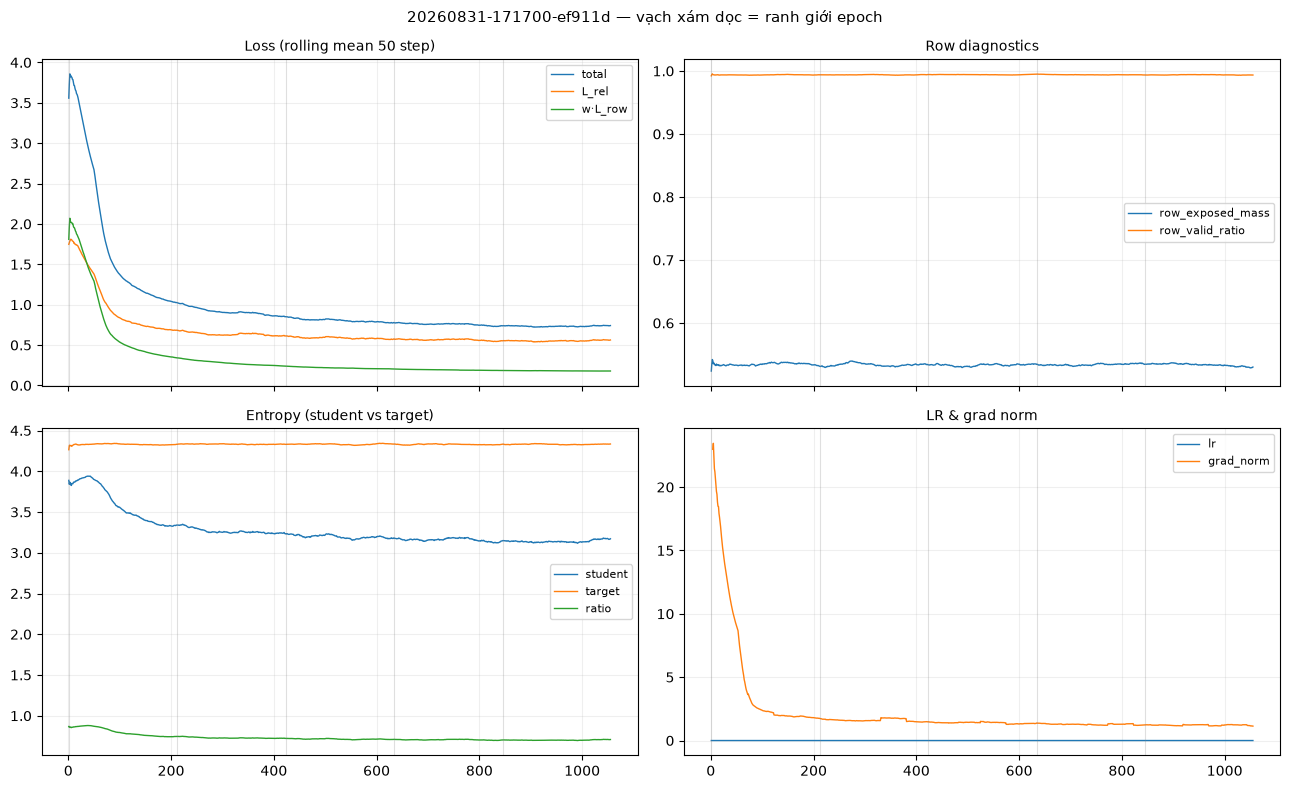

,first,last,mean,drop_in_epoch
epoch,,,,
1,3.5577,1.0498,1.5300,2.5079
2,0.9867,0.8960,0.8976,0.0907
3,0.7831,0.8679,0.7975,-0.0848
4,0.8400,0.6982,0.7535,0.1418
5,0.7229,0.8919,0.7335,-0.1690


In [17]:
# 8. Đồ thị step-level từ step_metrics.jsonl
import matplotlib.pyplot as plt

steps = read_jsonl(RUN_DIR / "step_metrics.jsonl", run_id)
if not steps:
    raise SystemExit("Không có step_metrics.jsonl cho run này.")

df = pd.DataFrame(steps).sort_values("global_step").set_index("global_step")
smooth = lambda s, w=50: s.rolling(w, min_periods=1).mean()

panels = [
    ("Loss (rolling mean 50 step)",
     [("loss", "total"), ("loss_rel", "L_rel"), ("loss_row_weighted", "w·L_row")]),
    ("Row diagnostics",
     [("row_exposed_mass", "row_exposed_mass"), ("row_valid_ratio", "row_valid_ratio")]),
    ("Entropy (student vs target)",
     [("student_entropy", "student"), ("target_entropy", "target"),
      ("student_entropy_ratio", "ratio")]),
    ("LR & grad norm",
     [("lr_next", "lr"), ("grad_norm", "grad_norm")]),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())
for ax, (title, series) in zip(axes.flat, panels):
    drawn = False
    for col, label in series:
        if col in df.columns and df[col].notna().any():
            ax.plot(smooth(df[col]), label=label, linewidth=1)
            drawn = True
    for e, s in epoch_starts.items():
        ax.axvline(s, color="gray", alpha=0.25, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    if drawn:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle(f"{run_id} — vạch xám dọc = ranh giới epoch", fontsize=11)
fig.tight_layout()
plt.show()

# Nhìn nhanh: loss step đầu/cuối mỗi epoch, để thấy còn giảm hay đã phẳng
ep_summary = df.groupby("epoch")["loss"].agg(["first", "last", "mean"]).round(4)
ep_summary["drop_in_epoch"] = (ep_summary["first"] - ep_summary["last"]).round(4)
display(ep_summary)


In [18]:
# 9. Calibrate quota → exposure offline từ graph.pt (không cần train)
# Mixture row của mỗi anchor nằm sẵn trong artifact; cumsum theo mass giảm dần
# cho thẳng đường cong "quota k thì exposure bao nhiêu" và trần khi quota→∞.
# Sanity: các mốc đã quan sát trong train log là quota 14 → ~0.44, 24 → ~0.52.
import numpy as np
import torch

art = torch.load(str(cache_dir / "graph.pt"), map_location="cpu")
pool_probs = art["pool_probs"].numpy()                 # (n_scales, n_items, width)
scales = art["metadata"]["diffusion_scales"]
w = np.array([1.0 / r for r in scales]); w /= w.sum()  # omega_r = 1/r, như sampler
mix = (pool_probs * w.reshape(-1, 1, 1)).sum(0)
cum = np.cumsum(-np.sort(-mix, axis=1), axis=1)

ceiling = cum[:, -1]
print(f"Trần exposure (quota→∞, do graph_k + truncation quyết định): "
      f"mean={ceiling.mean():.3f}  p10={np.quantile(ceiling, 0.1):.3f}")
print(f"{'quota':>6} {'mean':>7} {'p10':>7} {'p50':>7} {'p90':>7}")
for q in (14, 24, 34, 44, 64, 90, 128):
    m = cum[:, min(q, cum.shape[1]) - 1]
    print(f"{q:6d} {m.mean():7.3f} {np.quantile(m, 0.1):7.3f} "
          f"{np.quantile(m, 0.5):7.3f} {np.quantile(m, 0.9):7.3f}")

# Quota nhỏ nhất đạt coverage tau cho từng anchor — đọc ngược bảng trên.
for tau in (0.5, 0.6, 0.7, 0.8):
    reached = ceiling >= tau
    need = (cum >= tau).argmax(axis=1) + 1
    need = need[reached]
    print(f"tau={tau}: quota cần p50={np.median(need):.0f}  "
          f"p90={np.quantile(need, 0.9):.0f}  "
          f"({(~reached).mean():.1%} anchor không bao giờ đạt trần này)")


Trần exposure (quota→∞, do graph_k + truncation quyết định): mean=1.000  p10=1.000
 quota    mean     p10     p50     p90
    14   0.637   0.510   0.612   0.855
    24   0.750   0.647   0.727   0.890
    34   0.811   0.711   0.806   0.916
    44   0.848   0.759   0.852   0.936
    64   0.892   0.825   0.891   0.964
    90   0.924   0.879   0.920   0.983
   128   0.949   0.911   0.946   0.996
tau=0.5: quota cần p50=8  p90=14  (0.0% anchor không bao giờ đạt trần này)
tau=0.6: quota cần p50=14  p90=20  (0.0% anchor không bao giờ đạt trần này)
tau=0.7: quota cần p50=22  p90=32  (0.0% anchor không bao giờ đạt trần này)
tau=0.8: quota cần p50=34  p90=56  (0.0% anchor không bao giờ đạt trần này)
